In [3]:
import os
import numpy as np
import cv2

folder="/Users/ahmadgill/Documents/GitHub/LUMS-Academics/Second Semester/RoboTics641/Lab5/Robotics_assignment_lab5/train"
output=os.path.join(folder,"visualized")
os.makedirs(output,exist_ok=True)

palette={0:[0,0,0],1:[0,255,0],2:[255,0,0]}

for f in os.listdir(folder):
    if "_mask.png" not in f:
        continue

    mask_path=os.path.join(folder,f)
    image_name=f.replace("_mask.png",".jpg")

    mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

    color=np.zeros((mask.shape[0],mask.shape[1],3),dtype=np.uint8)

    for k,v in palette.items():
        color[mask==k]=v

    cv2.imwrite(os.path.join(output,image_name),cv2.cvtColor(color,cv2.COLOR_RGB2BGR))

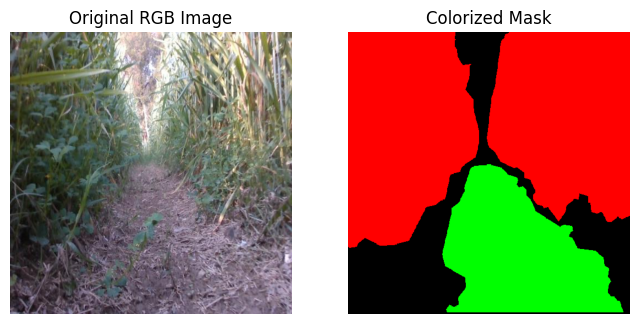

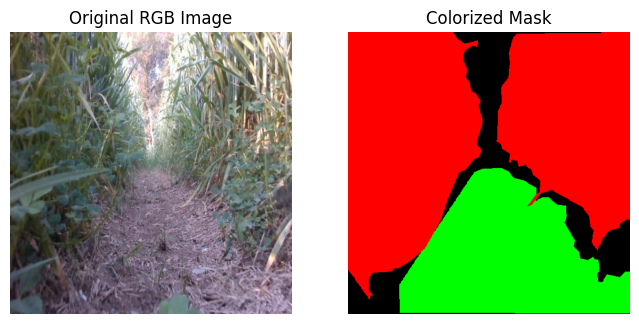

In [4]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

folder="/Users/ahmadgill/Documents/GitHub/LUMS-Academics/Second Semester/RoboTics641/Lab5/Robotics_assignment_lab5/train"

palette={0:[0,0,0],1:[0,255,0],2:[255,0,0]}

count=0

for f in os.listdir(folder):
    if "_mask.png" not in f:
        continue

    mask_path=os.path.join(folder,f)
    image_name=f.replace("_mask.png",".jpg")
    image_path=os.path.join(folder,image_name)

    if not os.path.exists(image_path):
        continue

    img=cv2.cvtColor(cv2.imread(image_path),cv2.COLOR_BGR2RGB)
    mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

    color=np.zeros((mask.shape[0],mask.shape[1],3),dtype=np.uint8)

    for k,v in palette.items():
        color[mask==k]=v

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Original RGB Image")

    plt.subplot(1,2,2)
    plt.imshow(color)
    plt.axis("off")
    plt.title("Colorized Mask")

    plt.show()

    count+=1
    if count==2:
        break